# Análise de Interpretabilidade e Performance de Busca Semântica - JusTRT6

Este notebook realiza a Análise Exploratória de Dados (EDA) e a visualização do espaço vetorial (embeddings) do projeto JusTRT6 Search.

In [1]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap

# Configurações de exibição
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

def get_connection():
    return psycopg2.connect(
        host=os.getenv("POSTGRES_HOST", "localhost"),
        database=os.getenv("POSTGRES_DB", "trt6"),
        user=os.getenv("POSTGRES_USER", "trt6"),
        password=os.getenv("POSTGRES_PASSWORD", "trt6"),
        port=os.getenv("POSTGRES_PORT", "5432")
    )

## 1. Carga de Dados

In [2]:
query = """
SELECT 
    a.id, 
    a.resultado_reclamante,
    a.desfecho,
    a.valor_causa,
    a.embedding
FROM core_analise a
WHERE a.embedding IS NOT NULL
"""

conn = get_connection()
df = pd.read_sql(query, conn)
conn.close()

print(f"Total de registros com embedding: {len(df)}")
df.head()

Total de registros com embedding: 1412


/tmp/ipykernel_64372/2702656721.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,resultado_reclamante,desfecho,valor_causa,embedding
0,1,perdeu,outro,98900.00,"[-0.059026815,0.09577801,-0.08698116,0.0982663..."
1,3,ganhou,acordo_favoravel,30796.57,"[-0.08850016,0.1847028,-0.12778309,0.027002007..."
2,6,ganhou,sentenca_procedente,100000.00,"[0.089562275,0.13370699,-0.09316168,-0.0269262..."
3,4,sem_decisao,outro,NaN,"[-0.0738548,0.1970496,-0.21891437,0.066619866,..."
4,5,ganhou,sentenca_procedente,50205.09,"[-0.09905847,0.2673185,-0.08813194,0.020600956..."


## 2. Análise Exploratória (EDA)

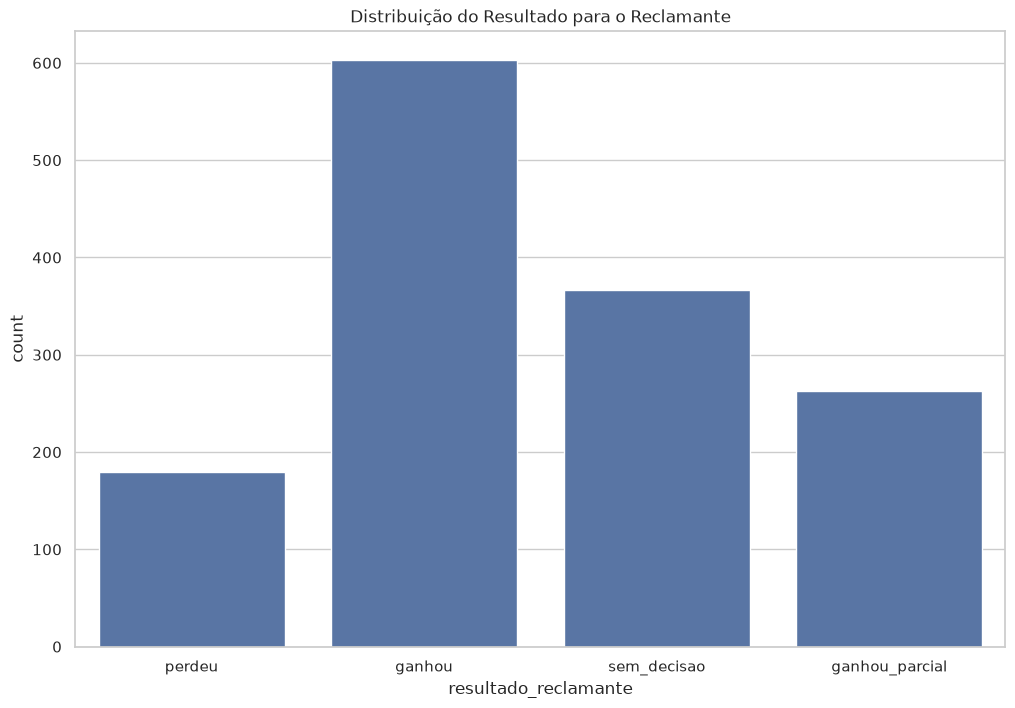

In [3]:
# Distribuição de Resultados
sns.countplot(data=df, x='resultado_reclamante')
plt.title("Distribuição do Resultado para o Reclamante")
plt.show()

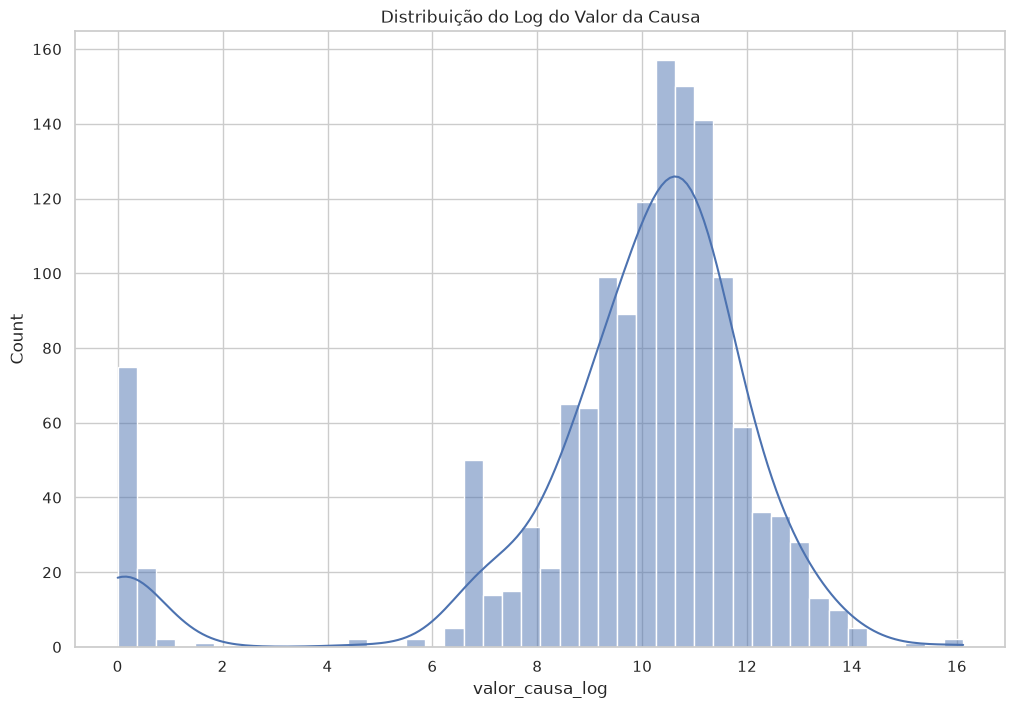

In [4]:
# Distribuição de Valores da Causa (log scale)
df['valor_causa_log'] = np.log1p(df['valor_causa'].fillna(0).astype(float))
sns.histplot(df['valor_causa_log'], kde=True)
plt.title("Distribuição do Log do Valor da Causa")
plt.show()

## 3. Visualização do Espaço Vetorial (Clusters)

In [5]:
# Converter strings de embedding para arrays numpy
# O pgvector retorna o embedding como uma string formatada '[0.1, 0.2, ...]'
def parse_embedding(eb_str):
    if isinstance(eb_str, str):
        return np.fromstring(eb_str.strip('[]'), sep=',')
    return eb_str

embeddings = np.stack(df['embedding'].apply(parse_embedding).values)
print(f"Shape da matriz de embeddings: {embeddings.shape}")

Shape da matriz de embeddings: (1412, 384)


/home/miguelsb/workspace/projetos6/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


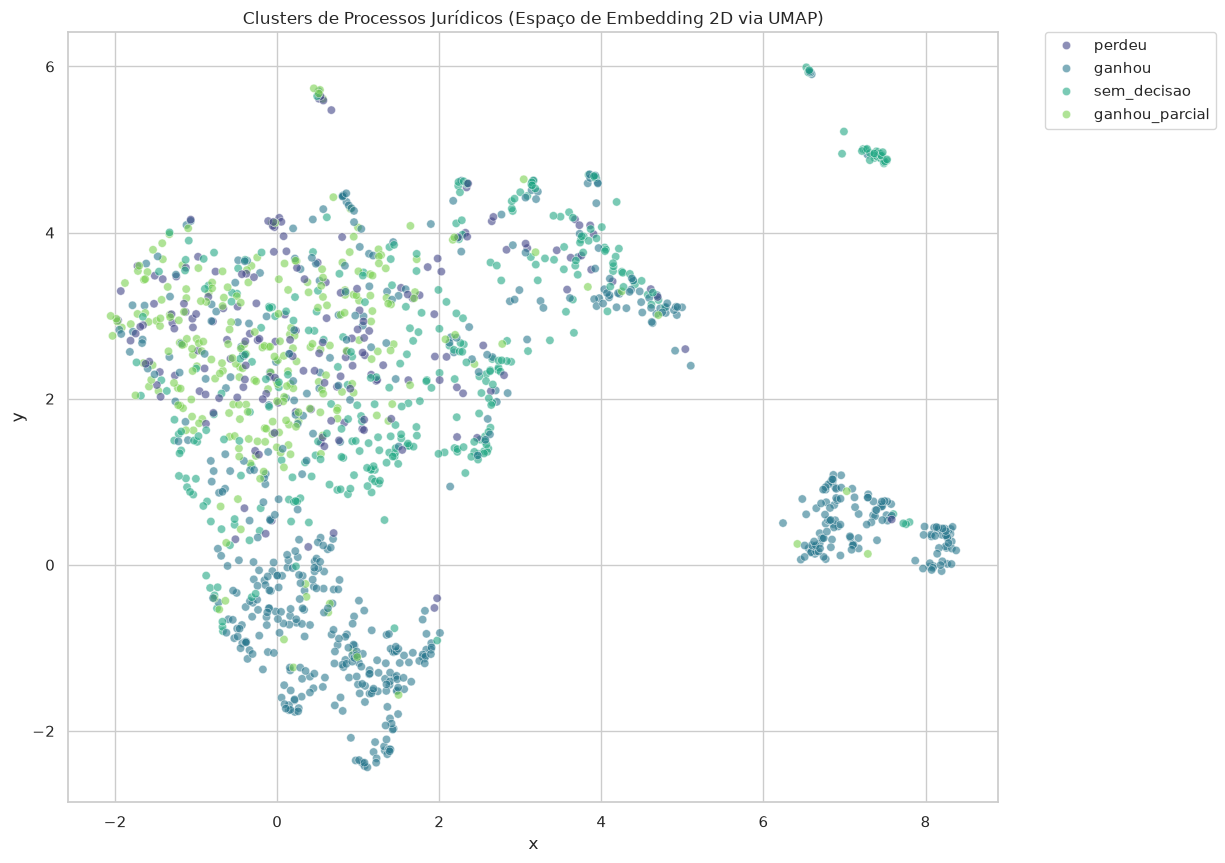

In [6]:
# Redução de Dimensionalidade com UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

df['x'] = embedding_2d[:, 0]
df['y'] = embedding_2d[:, 1]

plt.figure(figsize=(12, 10))
sns.scatterplot(data=df, x='x', y='y', hue='resultado_reclamante', palette='viridis', alpha=0.6)
plt.title("Clusters de Processos Jurídicos (Espaço de Embedding 2D via UMAP)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()